#  Project Description¶
"An end-to-end Machine Learning project that analyzes loan applicants data and builds a predictive model to accurately classify loan approvals using Random Forest."

## Objectives of the Project:
Perform Exploratory Data Analysis (EDA) to understand patterns in loan approval

Data Cleaning, handling outliers

Perform feature engineering and encoding of categorical variables

Visualize key insights using: Bar charts, Boxplots, Histograms, Scatter plots, Correlation heatmaps

Compare machine learning models: Logistic Regression, Decision Tree, Random Forest

Select and build the best-performing model (Random Forest)

Use the trained model to predict loan approval for new applicants

##  Skills Demonstrated in This Project
Python (Pandas, NumPy, Matplotlib, Seaborn)
Data Cleaning & EDA
Feature Engineering
Machine Learning with Scikit-learn
Model Evaluation (Accuracy, Confusion Matrix, Classification Report)


#  Dataset Description
This dataset represents real-world loan application data used to analyze customer profiles and predict whether a loan will be approved or rejected. Each row represents one applicant, and the columns include profile, financial, and asset-related information.

## Key Features in the Dataset:
-no_of_dependents – Number of dependents the applicant has

-education – Graduate / Not Graduate

-self_employed – Whether the applicant is self-employed

-income_annum – Annual income of the applicant

-loan_amount – Loan amount requested

-loan_term – Loan repayment time (years)

-cibil_score – Credit score indicating creditworthiness

-residential_assets_value – Value of residential assets

-commercial_assets_value – Value of commercial assets

-luxury_assets_value – Value of luxury assets

-bank_asset_value – Bank balance / financial assets

-loan_status (Target variable) – Approved (1) or Rejected (0)


# Import Python Libraries

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load dataset

df=pd.read_csv('loan_approval_dataset.csv')

In [3]:
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


# Data understanding

In [4]:
# data structure

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1   no_of_dependents           4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [5]:
#Summary statistics

df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [6]:
#change the values of all numeric columns of the dataframe upto 2 point decimal.


pd.options.display.float_format = "{:.2f}".format

In [7]:
#Summary statistics

df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00
mean,2135.00,2.50,5059123.92,15133450.46,10.90,599.94,7472616.54,4973155.31,15126305.93,4976692.43
std,1232.50,1.70,2806839.83,9043362.98,5.71,172.43,6503636.59,4388966.09,9103753.67,3250185.31
min,1.00,0.00,200000.00,300000.00,2.00,300.00,-100000.00,0.00,300000.00,0.00
25%,1068.00,1.00,2700000.00,7700000.00,6.00,453.00,2200000.00,1300000.00,7500000.00,2300000.00
50%,2135.00,3.00,5100000.00,14500000.00,10.00,600.00,5600000.00,3700000.00,14600000.00,4600000.00
75%,3202.00,4.00,7500000.00,21500000.00,16.00,748.00,11300000.00,7600000.00,21700000.00,7100000.00
max,4269.00,5.00,9900000.00,39500000.00,20.00,900.00,29100000.00,19400000.00,39200000.00,14700000.00


In [8]:
#how many loan application are there in the dataset?

df['loan_id'].count()

np.int64(4269)

In [10]:
#What percentage of applicants get loan approved vs rejected?

df['loan_status'].value_counts()

KeyError: 'loan_status'

In [11]:
#strip the white space from both sides

df.columns=df.columns.str.strip()

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [13]:
df['education'].unique()

array([' Graduate', ' Not Graduate'], dtype=object)

In [14]:
df['education']=df['education'].str.strip()
df['self_employed']=df['self_employed'].str.strip()
df['loan_status']=df['loan_status'].str.strip()

In [15]:
df['education'].unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [16]:
df['self_employed'].unique()

array(['No', 'Yes'], dtype=object)

In [17]:
df['loan_status'].unique()

array(['Approved', 'Rejected'], dtype=object)

In [18]:
#What percentage of applicants get loan approved vs rejected?

df['loan_status'].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

In [19]:
df['loan_status'].value_counts(normalize= True)*100

loan_status
Approved   62.22
Rejected   37.78
Name: proportion, dtype: float64

In [20]:
# Are there missing values in the dataset? Which columns are most affected?

df.isnull().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [21]:
#what are the data type of each feature (categorical vs numericAL)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [22]:
#Change datatype of 'loan_id' column

df['loan_id']=df['loan_id'].astype(str)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   object
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(9), object(4)
memory usage: 433.7+ KB


In [24]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


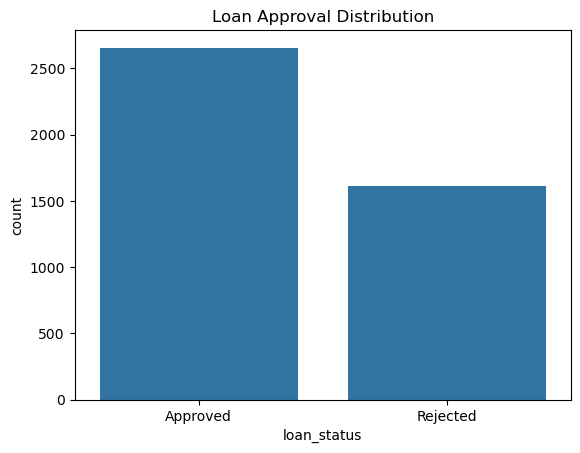

In [25]:
#Is the dataset balanced or imbalanced for loan approval?

sns.countplot(x= 'loan_status', data =df)
plt.title('Loan Approval Distribution')
plt.show()

# Exploratory Data Analysis(EDA)

### 1. Does employment type affect loan approval?

In [114]:
df['self_employed'].value_counts()

self_employed
1    2105
0    2077
Name: count, dtype: int64

In [115]:
emp_status=df.groupby(['self_employed','loan_status'])['loan_status'].count().unstack()
emp_status

loan_status,0,1
self_employed,,
0,785,1292
1,792,1313


In [116]:
emp_status['Total']=emp_status['Approved']+emp_status['Rejected']
emp_status

KeyError: 'Approved'

In [117]:
emp_status['Approval_%']=emp_status['Approved']/emp_status['Total']*100
emp_status

KeyError: 'Approved'

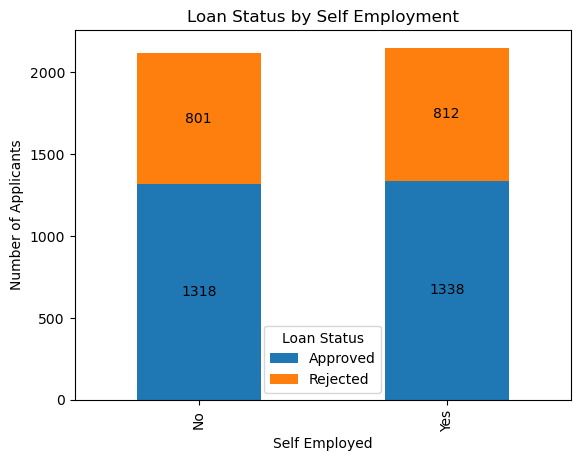

'This stacked bar chart clearly shows that approval rates are almost identical for self-employed \nand non self-employed applicants, meaning employment type does not strongly influence approval.'

In [31]:
# Plot stacked bar chart
# ax -> matplotlib axes object( the chart area)

ax= emp_status[['Approved','Rejected']].plot(kind='bar',stacked= True)

plt.title('Loan Status by Self Employment')
plt.xlabel('Self Employed')
plt.ylabel('Number of Applicants')
plt.legend(title='Loan Status')

for container in ax.containers:
    ax.bar_label(container, label_type='center')

plt.show()

"""This stacked bar chart clearly shows that approval rates are almost identical for self-employed 
and non self-employed applicants, meaning employment type does not strongly influence approval."""


### 2. Do graduates get higher approval rates than non-graduates?

In [32]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [33]:
df['education'].value_counts()

education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

In [34]:
education_status=df.groupby(['education','loan_status'])['loan_status'].count().unstack()
education_status

loan_status,Approved,Rejected
education,,
Graduate,1339,805
Not Graduate,1317,808


In [35]:
education_status['Total']=education_status['Approved']+education_status['Rejected']
education_status

loan_status,Approved,Rejected,Total
education,,,
Graduate,1339,805,2144
Not Graduate,1317,808,2125


In [36]:
education_status['Approved_%']=education_status['Approved']/education_status['Total']*100
education_status

loan_status,Approved,Rejected,Total,Approved_%
education,,,,
Graduate,1339,805,2144,62.45
Not Graduate,1317,808,2125,61.98


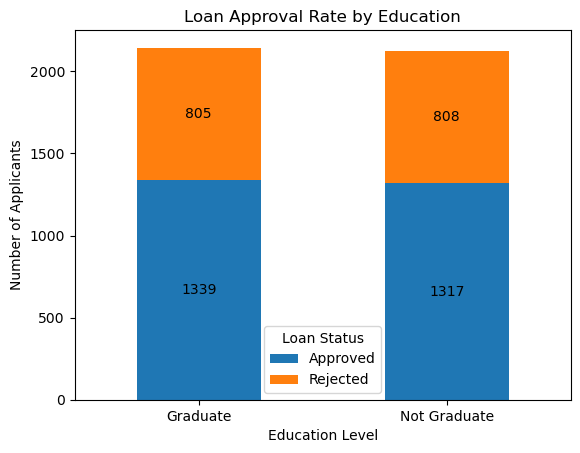

'This stacked bar chart clearly shows that approval rates are almost identical for graduate \nand non-graduate applicants, meaning education does not strongly influence approval.'

In [37]:
ax1= education_status[['Approved','Rejected']].plot(kind='bar',stacked= True)

plt.title('Loan Approval Rate by Education')
plt.xlabel('Education Level')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=0)
plt.legend(title='Loan Status')

for container in ax1.containers:
    ax1.bar_label(container, label_type='center')

plt.show()


"""This stacked bar chart clearly shows that approval rates are almost identical for graduate 
and non-graduate applicants, meaning education does not strongly influence approval."""


### 3. Does having more dependents reduce approval chances?

In [38]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [39]:
df['no_of_dependents'].value_counts()

no_of_dependents
4    752
3    727
0    712
2    708
1    697
5    673
Name: count, dtype: int64

In [40]:
dep_status=df.groupby(['no_of_dependents','loan_status'])['loan_status'].count().unstack()
dep_status

loan_status,Approved,Rejected
no_of_dependents,,
0,457,255
1,430,267
2,441,267
3,457,270
4,465,287
5,406,267


In [41]:
dep_status['Total']=dep_status['Approved']+dep_status['Rejected']
dep_status['Approved_%']=dep_status['Approved']/dep_status['Total']*100

dep_status

loan_status,Approved,Rejected,Total,Approved_%
no_of_dependents,,,,
0,457,255,712,64.19
1,430,267,697,61.69
2,441,267,708,62.29
3,457,270,727,62.86
4,465,287,752,61.84
5,406,267,673,60.33


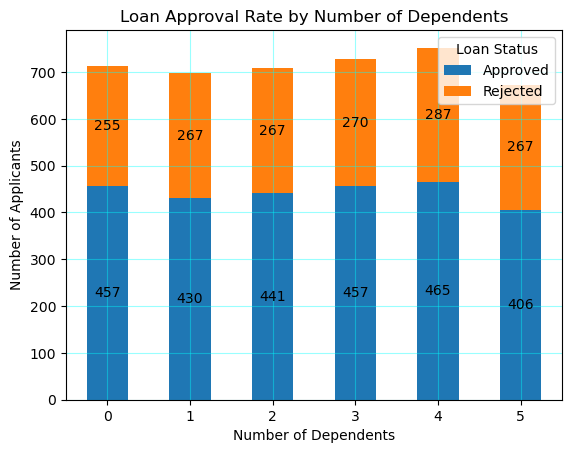

'The approval rate generally decreases as the number of dependents increases,\nindicating that higher financial responsibility reduces the likelihood of loan approval.'

In [42]:
# Plot stacked chart

ax2= dep_status[['Approved','Rejected']].plot(kind='bar',stacked= True)

plt.title('Loan Approval Rate by Number of Dependents')
plt.xlabel('Number of Dependents')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=0)
plt.legend(title='Loan Status')
plt.grid(True, color='cyan', alpha=0.4)

for container in ax2.containers:
    ax2.bar_label(container, label_type='center')

plt.show()

"""The approval rate generally decreases as the number of dependents increases,
indicating that higher financial responsibility reduces the likelihood of loan approval."""

### 4. What is the relationship between applicant income and loan approval?

In [43]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [44]:
df['income_annum'].describe()

count      4269.00
mean    5059123.92
std     2806839.83
min      200000.00
25%     2700000.00
50%     5100000.00
75%     7500000.00
max     9900000.00
Name: income_annum, dtype: float64

In [45]:
x=df.groupby(by= ['loan_status']).mean(numeric_only= True)['income_annum']
x

loan_status
Approved   5025903.61
Rejected   5113825.17
Name: income_annum, dtype: float64

In [46]:
type(x)

pandas.core.series.Series

<Axes: xlabel='loan_status'>

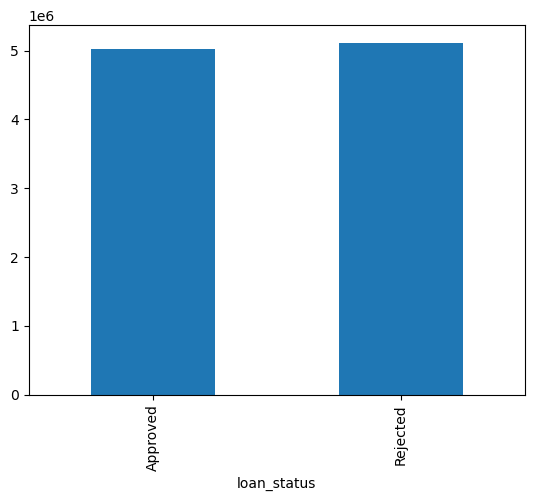

In [47]:
x.plot(kind='bar')

### How does loan amount vary between approved and rejected loans?

In [48]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [49]:
df['loan_amount'].describe()

count       4269.00
mean    15133450.46
std      9043362.98
min       300000.00
25%      7700000.00
50%     14500000.00
75%     21500000.00
max     39500000.00
Name: loan_amount, dtype: float64

In [50]:
df.groupby(by= ['loan_status']).mean(numeric_only= True)['loan_amount']

loan_status
Approved   15247251.51
Rejected   14946063.24
Name: loan_amount, dtype: float64

In [51]:
approved_amount= df[df['loan_status']=='Approved']['loan_amount']
approved_amount

0       29900000
6       33000000
8        2200000
10      11200000
13      31500000
          ...   
4261     7500000
4263    12700000
4265    11300000
4267    12800000
4268    29700000
Name: loan_amount, Length: 2656, dtype: int64

In [52]:
rejected_amount= df[df['loan_status']=='Rejected']['loan_amount']
rejected_amount

1       12200000
2       29700000
3       30700000
4       24200000
5       13500000
          ...   
4258    22600000
4259    11500000
4262     3000000
4264     2300000
4266    23900000
Name: loan_amount, Length: 1613, dtype: int64

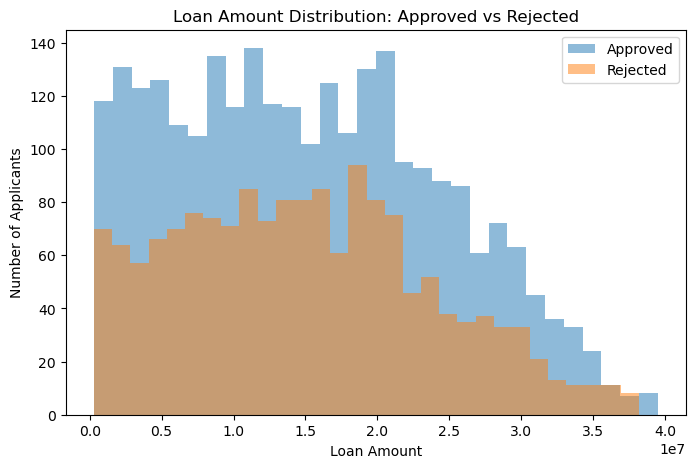

In [53]:
# Plot Histogram

plt.figure(figsize= (8,5))

plt.hist(approved_amount, bins= 30,alpha=0.5, label= 'Approved')
plt.hist(rejected_amount, bins= 30,alpha=0.5, label= 'Rejected')

plt.title('Loan Amount Distribution: Approved vs Rejected')
plt.xlabel('Loan Amount')
plt.ylabel('Number of Applicants')
plt.legend()

plt.show()


### 6. Does Cibil Score strongly influence loan approval?

In [54]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [55]:
df['cibil_score'].describe()

count   4269.00
mean     599.94
std      172.43
min      300.00
25%      453.00
50%      600.00
75%      748.00
max      900.00
Name: cibil_score, dtype: float64

In [56]:
df.groupby('loan_status')['cibil_score'].mean()

loan_status
Approved   703.46
Rejected   429.47
Name: cibil_score, dtype: float64

In [57]:
#Seperate loan amounts

approved_cibil=df[df['loan_status']=='Approved']['cibil_score']
rejected_cibil=df[df['loan_status']=='Rejected']['cibil_score']

In [58]:
approved_cibil

0       778
6       678
8       782
10      547
13      679
       ... 
4261    881
4263    865
4265    559
4267    780
4268    607
Name: cibil_score, Length: 2656, dtype: int64

In [59]:
rejected_cibil

1       417
2       506
3       467
4       382
5       319
       ... 
4258    346
4259    509
4262    540
4264    317
4266    457
Name: cibil_score, Length: 1613, dtype: int64

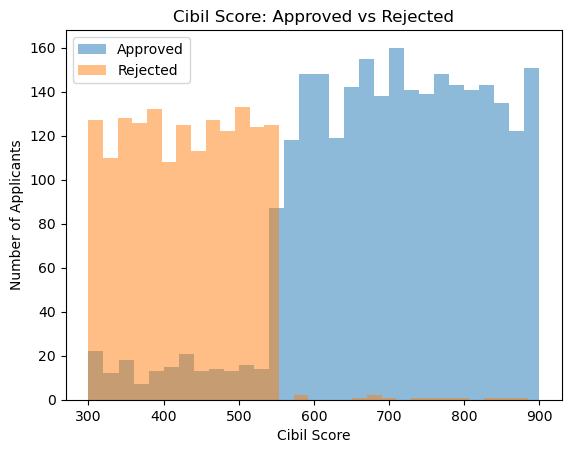

In [60]:
#Plot Histogram

plt.hist(approved_cibil, bins= 30, alpha= 0.5, label= 'Approved')
plt.hist(rejected_cibil, bins= 30, alpha= 0.5, label= 'Rejected')

plt.title('Cibil Score: Approved vs Rejected')
plt.xlabel('Cibil Score')
plt.ylabel('Number of Applicants')
plt.legend()

plt.show()


# Section 3: Data Visualization

### A. Compare Applicant Income vs Loan Amount(Scatter Plot)

In [61]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


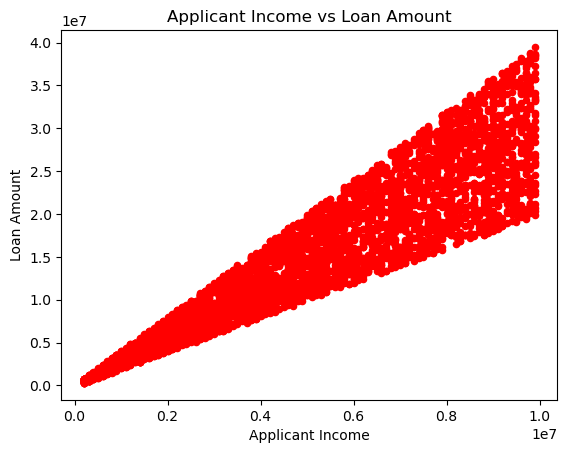

In [62]:
df.plot(x= 'income_annum', y= 'loan_amount', kind= 'scatter', color='red')

plt.title('Applicant Income vs Loan Amount')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')

plt.show()

### B. Show correlation heatmap of numerical data

In [63]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


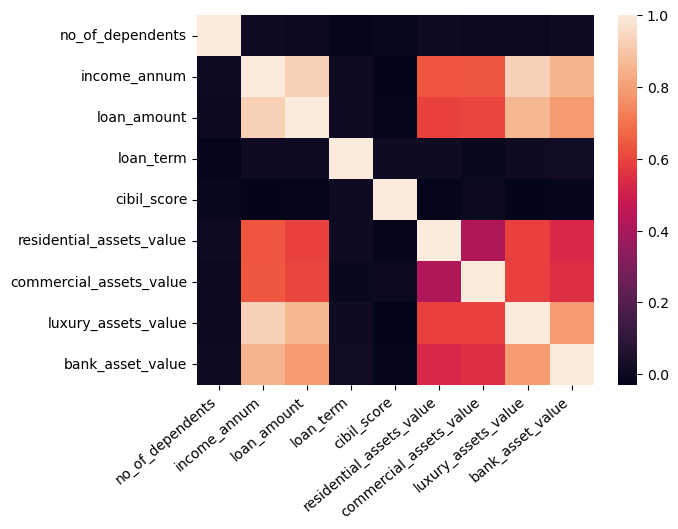

In [64]:
sns.heatmap(df.corr(numeric_only=True))

plt.xticks(rotation= 40, ha='right')
plt.show()

In [65]:
df['loan_amount'].corr(df['income_annum'])

np.float64(0.927469910987149)

In [66]:
df['luxury_assets_value'].corr(df['income_annum'])

np.float64(0.9291454207522588)

# Section 4: Data Cleaning and Feature Engineer

## Detect Outliers

In [67]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


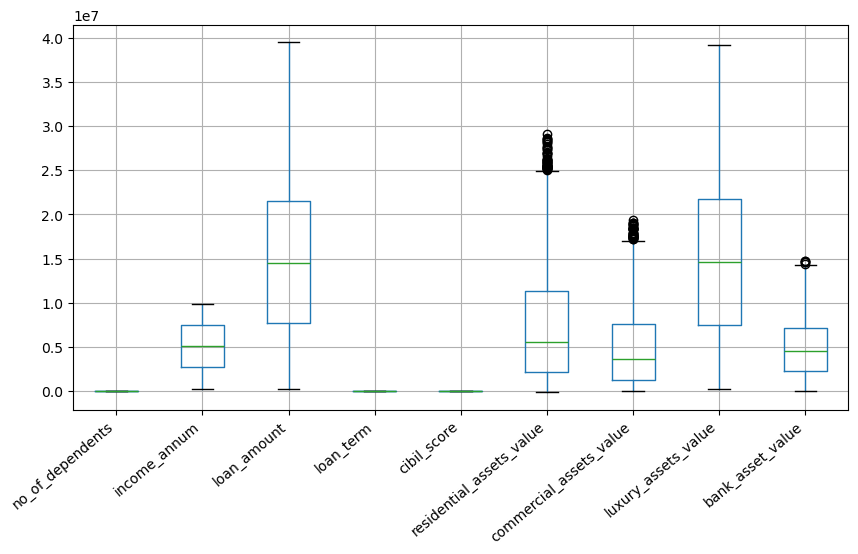

In [68]:
plt.figure(figsize=(10,5))
df.boxplot()
plt.xticks(rotation= 40, ha='right')
plt.show()

## Remove Outliers

In [69]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [70]:
df.describe()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00
mean,2.50,5059123.92,15133450.46,10.90,599.94,7472616.54,4973155.31,15126305.93,4976692.43
std,1.70,2806839.83,9043362.98,5.71,172.43,6503636.59,4388966.09,9103753.67,3250185.31
min,0.00,200000.00,300000.00,2.00,300.00,-100000.00,0.00,300000.00,0.00
25%,1.00,2700000.00,7700000.00,6.00,453.00,2200000.00,1300000.00,7500000.00,2300000.00
50%,3.00,5100000.00,14500000.00,10.00,600.00,5600000.00,3700000.00,14600000.00,4600000.00
75%,4.00,7500000.00,21500000.00,16.00,748.00,11300000.00,7600000.00,21700000.00,7100000.00
max,5.00,9900000.00,39500000.00,20.00,900.00,29100000.00,19400000.00,39200000.00,14700000.00


In [71]:
# Calculate Quartile

R_Q1=df['residential_assets_value'].quantile(0.25)
R_Q3=df['residential_assets_value'].quantile(0.75)

#Caclulate IQR
IQR= R_Q3-R_Q1

IQR

np.float64(9100000.0)

In [72]:
lower_limit= R_Q1- 1.5*IQR
upper_limit= R_Q3+ 1.5*IQR

In [122]:
df=df[(df['residential_assets_value'] >= lower_limit) & (df['residential_assets_value']<=upper_limit)]
df

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_Graduate,education_Not Graduate
1,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,False,True
2,3,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,True,False
4,5,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,False,True
5,0,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0,True,False
7,2,1,5700000,15000000,20,382,13200000,5700000,11800000,6000000,0,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4263,3,0,5000000,12700000,14,865,4700000,8100000,19500000,6300000,1,True,False
4264,5,1,1000000,2300000,12,317,2800000,500000,3300000,800000,0,True,False
4265,0,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1,False,True
4266,2,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0,False,True


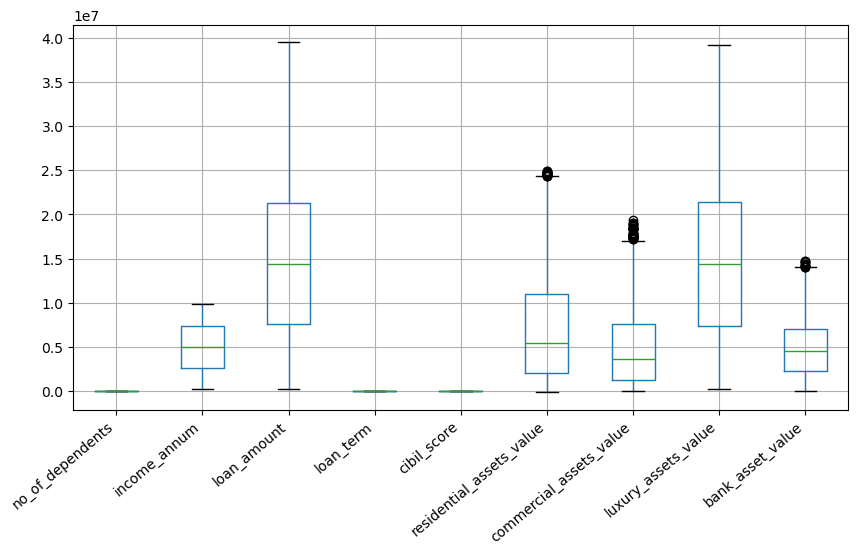

In [75]:
plt.figure(figsize=(10,5))
df.boxplot()
plt.xticks(rotation= 40, ha='right')
plt.show()

In [121]:
#Calculate Quartile

C_Q1=df['commercial_assets_value'].quantile(0.25)
C_Q3=df['commercial_assets_value'].quantile(0.75)

#IQR
C_IQR= C_Q3-C_Q1

C_IQR

lower_limit= C_Q1 - 1.5*C_IQR
upper_limit= C_Q3 + 1.5*C_IQR

#lower Outlier limit
df=df[(df['commercial_assets_value'] >= lower_limit) & (df['commercial_assets_value']<=upper_limit)]
df

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_Graduate,education_Not Graduate
1,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,False,True
2,3,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,True,False
3,3,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,True,False
4,5,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,False,True
5,0,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1,1000000,2300000,12,317,2800000,500000,3300000,800000,0,True,False
4265,0,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1,False,True
4266,2,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0,False,True
4267,1,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,1,False,True


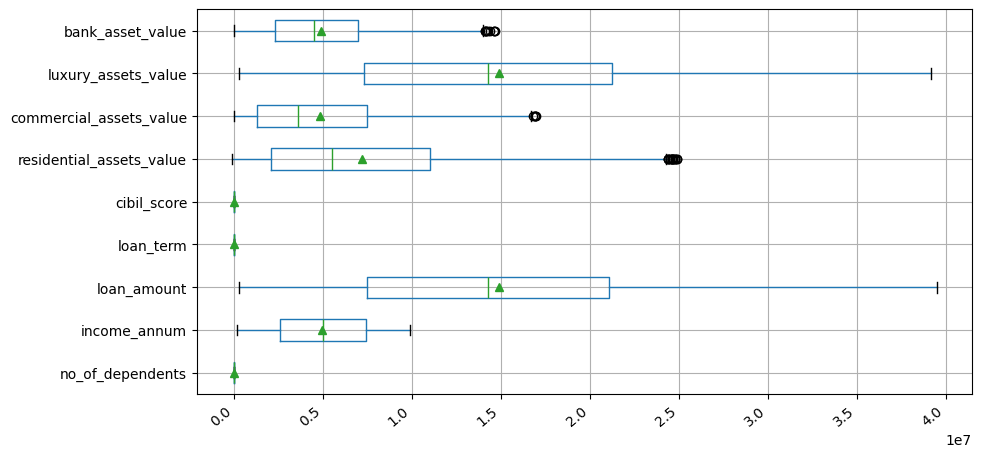

In [78]:
plt.figure(figsize=(10,5))
df.boxplot(showmeans=True, vert=False)
plt.xticks(rotation= 40, ha='right')
plt.show()

## Which features should be dropped(like Loan_ID)

In [119]:
df=df.drop('loan_id',axis= 1)
df

KeyError: "['loan_id'] not found in axis"

## Convert categorical data into numeric using Mapping, Label Encoding & One Hot Encoding

### Mapping

In [81]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected


In [82]:
df['loan_status']=df['loan_status'].map({'Approved': 1, 'Rejected': 0})

In [83]:
df

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0
5,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,0
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,1


### Label Encoding

In [120]:
# Encode Binary Column 

from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

df['self_employed']= le.fit_transform(df['self_employed'])
df

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_Graduate,education_Not Graduate
1,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,False,True
2,3,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,True,False
3,3,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,True,False
4,5,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,False,True
5,0,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,1,1000000,2300000,12,317,2800000,500000,3300000,800000,0,True,False
4265,0,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,1,False,True
4266,2,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,0,False,True
4267,1,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,1,False,True


### One-hot Encoding

In [86]:
df=pd.get_dummies(df, columns= ['education'])

#This avoids the dummy variable trap and keeps your model clean.
df

### Scale numerical features before model training

Feature Scaling is essential for models like Logistic Regression and SVM, but not for tree based models

In [88]:
df.head()

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_Graduate,education_Not Graduate
1,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,False,True
2,3,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,True,False
3,3,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,True,False
4,5,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,False,True
5,0,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0,True,False


# Model Building

In [90]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

X=df.drop('loan_status', axis=1)
y=df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

models = {"Logistic Regression" : LogisticRegression(max_iter = 1000),
          "Decision Tree" : DecisionTreeClassifier(),
          "Random Forest": RandomForestClassifier() 
         }

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(name, "Accuracy", accuracy_score(y_test, preds) )

Logistic Regression Accuracy 0.7968936678614098
Decision Tree Accuracy 0.970131421744325
Random Forest Accuracy 0.973715651135006


Why Random Forest:

1-Loan approval data typically has: 

2-Non-linear relationships (e.g., CIBIL score interacts with income)

3-Feature interactions (income + assets + dependents together matter)

4-Some noise and outliers 




Random Forest handles all of this very well because: 

1-It captures non-linear patterns 

2-It reduces overfitting compared to a single tree 

3-It works well even without perfect feature scaling 

4-It usually gives higher accuracy and better generalization

In [91]:
# Step 1: Split features and Target

X=df.drop('loan_status', axis=1)
y=df['loan_status']

In [92]:
# Step 2: Train-Test Split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, 
stratify=y)

In [93]:
#Step 3: Build Random Forest model

from sklearn.ensemble import RandomForestClassifier

rf_model= RandomForestClassifier(n_estimators= 200, max_depth=10, random_state=42)

In [94]:
rf_model.fit(X_train,y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [95]:
#Step 4: Make Prediction

y_pred=rf_model.predict(X_test)

In [96]:
#Step 5: Evaluate the model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('Accuracy:', accuracy_score(y_test,y_pred)*100,'%')
print('Classification Report:',classification_report(y_test,y_pred))
print('Confusion Matrix:', confusion_matrix(y_test,y_pred))

Accuracy: 97.2520908004779 %
Classification Report:               precision    recall  f1-score   support

           0       0.97      0.95      0.96       316
           1       0.97      0.98      0.98       521

    accuracy                           0.97       837
   macro avg       0.97      0.97      0.97       837
weighted avg       0.97      0.97      0.97       837

Confusion Matrix: [[301  15]
 [  8 513]]


In [97]:
#Step 6: Feature Importance

feature_importance=pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending= False)
feature_importance

cibil_score                0.83
loan_term                  0.06
loan_amount                0.02
luxury_assets_value        0.02
income_annum               0.01
residential_assets_value   0.01
commercial_assets_value    0.01
bank_asset_value           0.01
no_of_dependents           0.01
self_employed              0.00
education_Not Graduate     0.00
education_Graduate         0.00
dtype: float64

<Axes: >

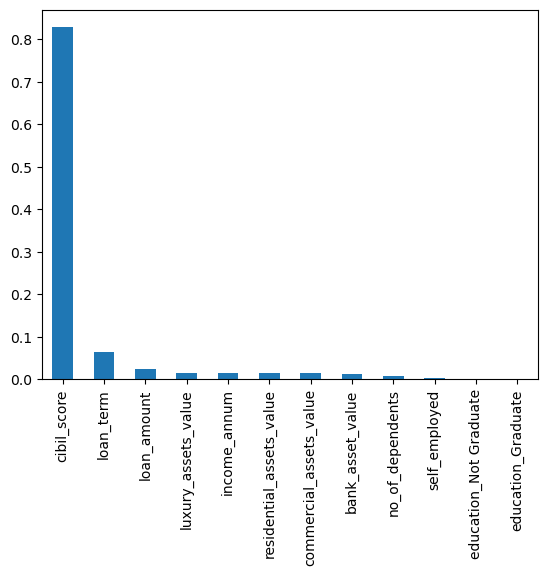

In [98]:
import matplotlib as plt

feature_importance.plot(kind='bar')

# Model Prediction

In [99]:
df.head()

,no_of_dependents,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,education_Graduate,education_Not Graduate
1,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,False,True
2,3,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,True,False
3,3,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,True,False
4,5,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,False,True
5,0,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0,True,False


In [100]:
#For a new customer
new_applicant = {
    'no_of_dependents': 4,
    'self_employed': 1,    
    'income_annum': 600000,
    'loan_amount': 250000,
    'loan_term': 36,
    'cibil_score': 900,
    'residential_assets_value': 30,
    'commercial_assets_value': 0,
    'luxury_assets_value': 0,
    'bank_asset_value': 5000,
    'education_Graduate': 1,
    'education_Not Graduate':1,
}

new_df = pd.DataFrame([new_applicant])
new_df

In [118]:
prediction=rf_model.predict(new_df)
prediction

array([1])

# Save Model

In [109]:
import joblib

joblib.dump(rf_model, 'Loan_approval_prediction.pkl')

['Loan_approval_prediction.pkl']

In [110]:
#Load and use

loaded_model=joblib.load('Loan_approval_prediction.pkl')
loaded_model

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)